In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/yasserh/breast-cancer-dataset/breast-cancer.csv


In [ ]:
# 📊 ROC = Receiver Operating Characteristic
# It checks how well the model separates Class 0 and Class 1

# 📈 ROC Curve = Graph between:
# X-axis → FPR (False Positive Rate) ❌
# Y-axis → TPR (True Positive Rate / Recall) ✅

# TPR = TP / (TP + FN)
# → Out of all actual positives,
# how many were correctly predicted

# FPR = FP / (FP + TN)
# → Out of all actual negatives,
# how many were wrongly predicted positive

# 🎯 AUC = Area Under Curve
# It measures the total performance of the ROC Curve

# ROC-AUC Score tells:
# How good the model is at distinguishing between classes

# Score closer to 1 → Excellent model 🚀
# Score near 0.5 → Random guessing 😅
# Score below 0.5 → Very poor model ❌

In [2]:
df = pd.read_csv('/kaggle/input/datasets/yasserh/breast-cancer-dataset/breast-cancer.csv')

In [3]:
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [4]:
df.isnull().sum()

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [5]:
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

In [6]:
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,1,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,1,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,1,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,1,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [7]:
df.drop('id',axis =1,inplace = True )

In [8]:
X = df.iloc[:,1:31]
X


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [9]:
y = df.iloc[:,0]
y

0      1
1      1
2      1
3      1
4      1
      ..
564    1
565    1
566    1
567    1
568    0
Name: diagnosis, Length: 569, dtype: int64

In [10]:
from sklearn.model_selection import train_test_split
# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [11]:
X_train

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
68,9.029,17.33,58.79,250.5,0.10660,0.14130,0.31300,0.04375,0.2111,0.08046,...,10.310,22.65,65.50,324.7,0.14820,0.43650,1.25200,0.17500,0.4228,0.11750
181,21.090,26.57,142.70,1311.0,0.11410,0.28320,0.24870,0.14960,0.2395,0.07398,...,26.680,33.48,176.50,2089.0,0.14910,0.75840,0.67800,0.29030,0.4098,0.12840
63,9.173,13.86,59.20,260.9,0.07721,0.08751,0.05988,0.02180,0.2341,0.06963,...,10.010,19.23,65.59,310.1,0.09836,0.16780,0.13970,0.05087,0.3282,0.08490
248,10.650,25.22,68.01,347.0,0.09657,0.07234,0.02379,0.01615,0.1897,0.06329,...,12.250,35.19,77.98,455.7,0.14990,0.13980,0.11250,0.06136,0.3409,0.08147
60,10.170,14.88,64.55,311.9,0.11340,0.08061,0.01084,0.01290,0.2743,0.06960,...,11.020,17.45,69.86,368.6,0.12750,0.09866,0.02168,0.02579,0.3557,0.08020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,8.888,14.64,58.79,244.0,0.09783,0.15310,0.08606,0.02872,0.1902,0.08980,...,9.733,15.67,62.56,284.4,0.12070,0.24360,0.14340,0.04786,0.2254,0.10840
106,11.640,18.33,75.17,412.5,0.11420,0.10170,0.07070,0.03485,0.1801,0.06520,...,13.140,29.26,85.51,521.7,0.16880,0.26600,0.28730,0.12180,0.2806,0.09097
270,14.290,16.82,90.30,632.6,0.06429,0.02675,0.00725,0.00625,0.1508,0.05376,...,14.910,20.65,94.44,684.6,0.08567,0.05036,0.03866,0.03333,0.2458,0.06120
435,13.980,19.62,91.12,599.5,0.10600,0.11330,0.11260,0.06463,0.1669,0.06544,...,17.040,30.80,113.90,869.3,0.16130,0.35680,0.40690,0.18270,0.3179,0.10550


In [12]:
y_train

68     0
181    1
63     0
248    0
60     0
      ..
71     0
106    0
270    0
435    1
102    0
Name: diagnosis, Length: 455, dtype: int64

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

In [15]:
y_pred = model.fit(X_train,y_train)
y_pred

LogisticRegression()

In [16]:
 y_prediction = model.predict(X_test)

In [17]:
from sklearn.metrics import accuracy_score

In [18]:
print(accuracy_score(y_test, y_prediction))

0.9736842105263158


In [19]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix

In [20]:
accuracy_score(y_test, y_prediction)

0.9736842105263158

In [21]:
print(recall_score(y_test, y_prediction))

0.9534883720930233


In [22]:
print(f1_score(y_test, y_prediction))

0.9647058823529412


In [23]:
print(confusion_matrix(y_test, y_prediction))

[[70  1]
 [ 2 41]]


**ROC,ROC-AUC**

In [24]:
# Here model.predict() gives final class labels
# directly as 0 or 1
# Default threshold = 0.5 is used internally
y_predict_Previous = model.predict(X_test)
y_predict_Previous

array([0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 1])

In [25]:
# Instead of predict(), we use predict_proba()
# It gives probability scores
# not direct 0 or 1

# [:,1] is used because ROC needs🔥
# probability of positive class only
# In this dataset:
# 1 = Malignant (Positive Class)
# 0 = Benign (Negative Class)
# [:,0] = probability of class 0
# [:,1] = probability of class 1
# So we use [:,1]
# to get probability of malignant cancer

y_prob = model.predict_proba(X_test)[:,1]

In [77]:
y_prob = model.predict_proba(X_test)[:,1]
from sklearn.metrics import roc_auc_score,roc_curve
auc_score = roc_auc_score(y_test, y_prob)
print("\nROC-AUC Score:")
print(auc_score)


ROC-AUC Score:
0.99737962659679


In [ ]:
# roc_curve() gives 3 outputs:

# 1. fpr = False Positive Rate
# Formula:
# FPR = FP / (FP + TN)

# It means:
# Out of all actual negative cases,
# how many were wrongly predicted as positive

# Example:
# Out of all innocent people,
# how many were wrongly flagged as terrorists


# 2. tpr = True Positive Rate
# Also called Recall or Sensitivity

# Formula:
# TPR = TP / (TP + FN)

# It means:
# Out of all actual positive cases,
# how many were correctly predicted as positive

# Example:
# Out of all real terrorists,
# how many were correctly caught


# 3. thresholds = Cutoff values

# Threshold means:
# From which probability value
# we should predict class 1

# Rule:
# if probability >= threshold:
#     predict = 1
# else:
#     predict = 0

# Example:
# threshold = 0.5

# if probability >= 0.5
# predict positive

# if probability < 0.5
# predict negative


# roc_curve() automatically tries
# many threshold values like:

# [inf, 1, 0]

# and for each threshold
# it calculates:

# FPR and TPR

# then uses them to draw ROC Curve

In [51]:
# roc_curve() automatically tests many thresholds
# like:
# 1.0, 0.9, 0.8, 0.7, 0.5, 0.3 ...

# For each threshold it calculates:
# - TPR (True Positive Rate)
# - FPR (False Positive Rate)

# NOTE:
# ROC should use probability values, not final predictions

# Correct:
# y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
print(thresholds)
print(tpr)
print(fpr)

[           inf 1.00000000e+00 7.76680319e-01 5.42699821e-01
 4.84826685e-01 1.13099081e-01 8.41633901e-02 8.18375684e-07]
[0.         0.02325581 0.95348837 0.95348837 0.97674419 0.97674419
 1.         1.        ]
[0.         0.         0.         0.01408451 0.01408451 0.09859155
 0.09859155 1.        ]


In [52]:
# Create table
roc_table = pd.DataFrame({
    "Threshold": thresholds,
    "TPR": tpr,
    "FPR": fpr
})

# Show table
print(roc_table)

      Threshold       TPR       FPR
0           inf  0.000000  0.000000
1  1.000000e+00  0.023256  0.000000
2  7.766803e-01  0.953488  0.000000
3  5.426998e-01  0.953488  0.014085
4  4.848267e-01  0.976744  0.014085
5  1.130991e-01  0.976744  0.098592
6  8.416339e-02  1.000000  0.098592
7  8.183757e-07  1.000000  1.000000


In [ ]:
# FPR = [0. , 0.014 , 1. ]
# TPR = [0. , 0.953 , 1. ]

# TPR = True Positive Rate
# Formula:
# TPR = TP / (TP + FN)

# It means:
# Out of all actual positive cases,
# how many were correctly caught


# TPR = 0

# Means:
# 0% positives were caught

# Example:
# If 10 terrorists exist
# and security catches 0

# Then:
# TPR = 0

# Very bad


# TPR = 1

# Means:
# 100% positives were caught

# Example:
# If 10 terrorists exist
# and security catches all 10

# Then:
# TPR = 1

# Perfect


# FPR = False Positive Rate
# Formula:
# FPR = FP / (FP + TN)

# It means:
# Out of all actual negative cases,
# how many were wrongly flagged


# FPR = 0

# Means:
# 0% negatives were wrongly flagged

# Example:
# If 100 innocent people exist
# and none are wrongly stopped

# Then:
# FPR = 0

# Perfect


# FPR = 1

# Means:
# 100% negatives were wrongly flagged

# Example:
# If 100 innocent people exist
# and all 100 are wrongly stopped

# Then:
# FPR = 1

# Very bad


# ROC Points

# (0 , 0)
# Nobody predicted positive

# (0.014 , 0.953)
# Very good point
# Only 1.4% wrong flags
# 95.3% positives caught

# (1 , 1)
# Everyone predicted positive


# Best model:
# TPR should be close to 1
# FPR should be close to 0

In [29]:
# roc_auc_score() gives final score
# called AUC = Area Under Curve
from sklearn.metrics import roc_auc_score

auc_score = roc_auc_score(y_test, y_prob)

print("\nROC-AUC Score:")
print(auc_score)


ROC-AUC Score:
0.99737962659679


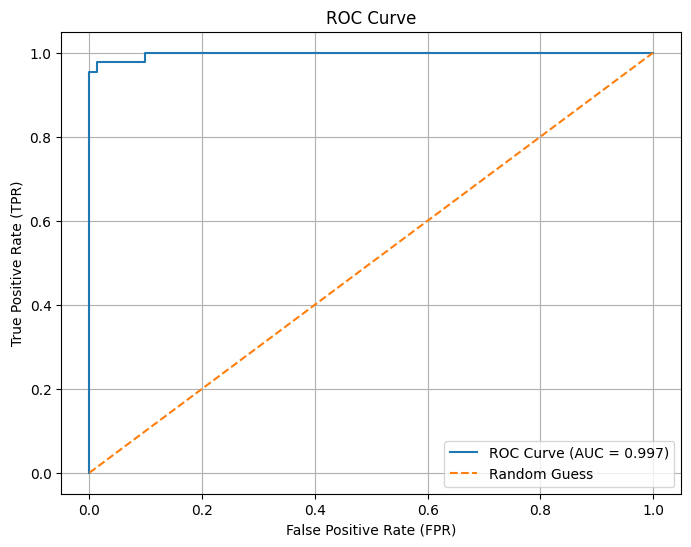

In [38]:
# =========================================
# Step 7: Plot ROC Curve
# =========================================

plt.figure(figsize=(8,6))

# ROC Curve
plt.plot(
    fpr,
    tpr,
    label=f"ROC Curve (AUC = {auc_score:.3f})"
)

# Random Guess Line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Guess"
)

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve")
plt.legend()
plt.grid()

plt.show()

In [40]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

best_index = np.argmax(tpr - fpr)

best_threshold = thresholds[best_index]

print(best_threshold)

0.48482668465556283


In [73]:
# Set threshold manually to 0.7

y_prob = model.predict_proba(X_test)[:, 1]

custom_threshold = 0.48

y_predo = (y_prob >= custom_threshold).astype(int)

print(y_predo)

[0 1 1 0 0 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1
 0 1 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 1 0 0 1 1 0 0 0 1 1 0 0 1 1 0 1
 0 0 0 1 0 0 1 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1 0 1 1 0 0 0 1 0 0 1
 0 1 1]


In [74]:
confusion_matrix(y_test,y_predo)

array([[70,  1],
       [ 1, 42]])

In [83]:
#y_prob = model quality checking and development not deployment it give 
#only evaluation and best probability
y_prob = model.predict_proba(X_test)[:,1]
from sklearn.metrics import roc_auc_score
auc_score = roc_auc_score(y_test, y_prob)
print("\nROC-AUC Score:")
print(auc_score)
#Accury is higher the below beacuse it have more information that 
#below and and probability but the model should give answer in 0 or 1 


ROC-AUC Score:
0.99737962659679


In [80]:
# roc_auc_score() gives final score
# called AUC = Area Under Curve
y_prob = model.predict_proba(X_test)[:, 1]
# Instead of default threshold = 0.50,
# we are using a custom threshold = 0.4848
# Rule:
y_pred_best = (y_prob >= 0.4848).astype(int)
# If probability >= 0.4848
# → Predict class 1 (Positive class)
# Else
# → Predict class 0 (Negative class)
# .astype(int)
# → Converts:
# True  → 1
# False → 0
from sklearn.metrics import roc_auc_score
auc_score = roc_auc_score(y_test, y_pred_best)
print("\nROC-AUC Score:")
print(auc_score)
#best threshold = final decision rule for deployment
# To improve model performance by using the best threshold
# instead of the default 0.50 threshold


ROC-AUC Score:
0.981329839502129



ROC-AUC Score:
0.99737962659679
